# Drifing Gaussian

## Imports

In [1]:
import dolfinx as dx
import dolfinx.plot as dxp
from mpi4py import MPI
import pyvista as pv
import ufl

## Setup

In [2]:
pv.set_jupyter_backend('static')
pvpl = pv.Plotter()

## Parameters

In [19]:
h0 = 1.0 # Constant height
u0 = 1.0 # Constant rightward flow
v0 = 0.0 # No vertical flow
nx = 10 # Cell resolution
dt = 0.01 # Time step
nt = 1000 # 10 s of simulation

In [20]:
# Initial condition
x0 = 0.5
y0 = 0.5
r0 = 0.1
def iota0(x, y):
    return exp(-((x - x0) ** 2 + (y - y0) ** 2)/ r0 ** 2)

## Mesh

In [5]:
# Define a simple
domain = dx.mesh.create_unit_square(MPI.COMM_WORLD, nx, nx, cell_type=dx.mesh.CellType.triangle)

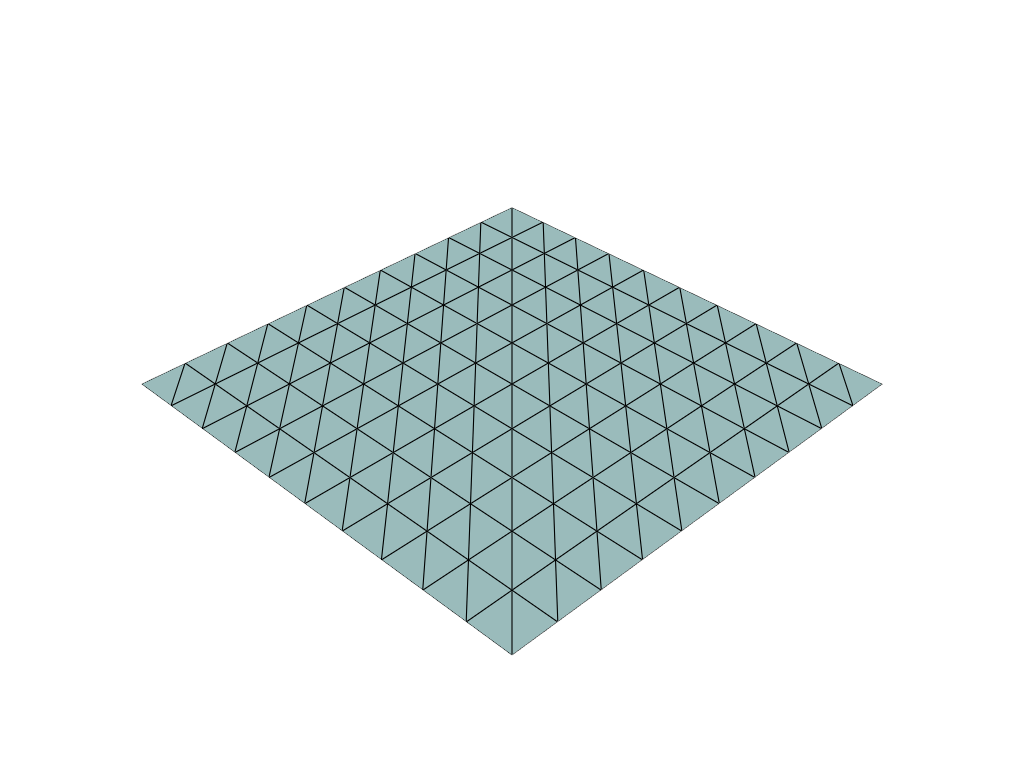

In [6]:
topology, cell_types, geometry = dxp.vtk_mesh(domain, domain.topology.dim)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)
pvpl.add_mesh(grid, show_edges=True, color="lightblue")
pvpl.show()

## FEM Formulation

In [7]:
# Linear DG space
V = dx.fem.functionspace(domain, ('Discontinuous Lagrange', 1))

In [8]:
# Trial and test functions
iota = ufl.TrialFunction(V) # Conserved quantity iota = c * h
phi = ufl.TestFunction(V) # Scalar test function

In [9]:
# Additional functions
h = dx.fem.Constant(domain, h0)
v = dx.fem.Constant(domain, (u0, v0))
n = ufl.FacetNormal(domain)

In [10]:
# Hyperbolic formulation
def F(U):
    """Flux function F(U)"""
    return U * v
def J(U):
    """Flux Jacobian dF/dU(U)"""
    return v

In [11]:
# Flux treatments
def fluxn_upwind(F, J, U, n):
    """Upwind flux treatment for a scalar law.

    The value of the flux at the interface is chosen to be either F(U+) or
    F(U-), depending on the characteristic speeds. If the characteristic is
    going from element + to -, the flux from + is used, and vice versa. If
    the two elements' characteristics "disagree," an average is used instead.
    
    Args:
        F (callable): A single-argument Python function that returns a UFL vector given a scalar state.
        J (callable): A single-argument Python function that returns dF/dU given a scalar state.
        U (ufl.Coefficient or ufl.Argument): The scalar state variable.
        n (ufl.FacetNormal): The normal at the cell interface.

    Returns:
        ufl.Conditional: The upwinded flux projected on the normal.
    """

    # Project onto outward normal of + to get speeds
    J_plus_n_plus = ufl.dot(J(U('+')), n('+')) # Characteristic speed at +
    J_minus_n_plus = ufl.dot(J(U('-')), n('+')) # Characteristic speed at -, using +'s normal

    # Determine whether wave is entering or leaving +
    leaving_plus = ufl.and_condition(J_plus_n_plus > 0.0, J_minus_n_plus > 0.0)
    entering_plus = ufl.and_condition(J_plus_n_plus < 0.0, J_minus_n_plus < 0.0)

    # Choose appropriate flux from source element
    F_plus = F(U('+'))
    F_minus = F(U('-'))
    return ufl.dot(ufl.conditional(
        leaving_plus,
        F_plus,
        ufl.conditional(
            entering_plus,
            F_minus,
            0.5 * (F_plus + F_minus)
        )
    ), n('+'))

def fluxn_llf(F, J, U, n):
    """Local Lax-Friedrichs treatment for a scalar law.

    This is 0.5 * (F(U+) + F(U-)) + 0.5 * lambda * (U+ - U-)

    Args:
        F (callable): A single-argument Python function that returns a UFL vector given a scalar state.
        J (callable): A single-argument Python function that returns dF/dU given a scalar state.
        U (ufl.Coefficient or ufl.Argument): The scalar state variable.
        n (ufl.FacetNormal): The normal at the cell interface.

    Returns:
        ufl.Conditional: The Local Lax-Friedrichs flux projected on the normal.
    """

    # Project onto outward normal of + to get speeds
    abs_J_plus_n = abs(ufl.dot(J(U('+')), n('+'))) # Characteristic speed at +
    abs_J_minus_n = abs(ufl.dot(J(U('-')), n('+'))) # Characteristic speed at -
    lam = ufl.max_value(abs_J_plus_n, abs_J_minus_n)

    # Get fluxes from both sides
    F_plus = F(U('+'))
    F_minus = F(U('-'))

    # Return LLF formula
    return 0.5 * ufl.dot(F_plus + F_minus, n('+')) + 0.5 * lam * (U('+') - U('-'))
    

In [12]:
# Manual upwinding
# vn = ufl.dot(v, n)
# iota_upwind = ufl.conditional(vn('+') > 0.0, iota('+'), iota('-')) # Upwind
# F_boundary = F(iota_upwind)

In [13]:
# Use a particular flux treatment
F_interior = F(iota)
Fn_boundary = fluxn_llf(F, J, iota, n)

In [14]:
# UFL form
# General form is dU/dt * phi + B(iota, phi) = 0
M_form = iota * phi * ufl.dx # Mass matrix
B_interior = -ufl.dot(F_interior, ufl.grad(phi)) * ufl.dx
B_interior_facets = Fn_boundary * ufl.jump(phi) * ufl.dS
#B_boundary = 0 * ufl.ds
B_form = B_interior + B_interior_facets # RHS for time stepping

## Assembly

## Solution

## Visualization